In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from wordcloud import WordCloud
from textblob import TextBlob
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120})

SUBREDDIT_COLORS = {
    'ProgrammerHumor' : '#4C72B0',
    'Animemes'        : '#DD8452',
    'Funnymemes'      : '#55A868',
    'okbuddyretard'   : '#C44E52',
    'dankmemes'       : '#8172B3',
    'shitposting'     : '#937860',
    'engineeringmemes': '#DA8BC3',
}

✅ Libraries loaded!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
DATA_PATH = '/content/drive/MyDrive/AMLProject/data.csv'

df = pd.read_csv(DATA_PATH)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4821 entries, 0 to 4820
Data columns (total 31 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Title                4821 non-null   object 
 1   Author               4821 non-null   object 
 2   Total Karma          4821 non-null   int64  
 3   Comment Karma        4821 non-null   int64  
 4   Cake Day             4821 non-null   object 
 5   Post URL             4821 non-null   object 
 6   Created Time         4821 non-null   object 
 7   Upvotes              4821 non-null   int64  
 8   Upvote Ratio         4821 non-null   float64
 9   Number of Comments   4821 non-null   int64  
 10  Category             4821 non-null   object 
 11  Time of Day          4821 non-null   object 
 12  File Name            4821 non-null   object 
 13  Extracted Text       4821 non-null   object 
 14  log_upvotes          4821 non-null   float64
 15  title_len            4821 non-null   i

In [29]:
df['Created Time'] = pd.to_datetime(df['Created Time'])

print(f"Date range: {df['Created Time'].min().date()} → {df['Created Time'].max().date()}")
print(f"Subreddits: {df['Category'].nunique()}")
print(f"Viral posts: {df['is_viral'].sum()} ({df['is_viral'].mean()*100:.1f}%)")
print(f"Missing values: {df.isnull().sum().sum()}")

Date range: 2024-04-21 → 2025-04-04
Subreddits: 7
Viral posts: 1206 (25.0%)
Missing values: 0


# Target Variable

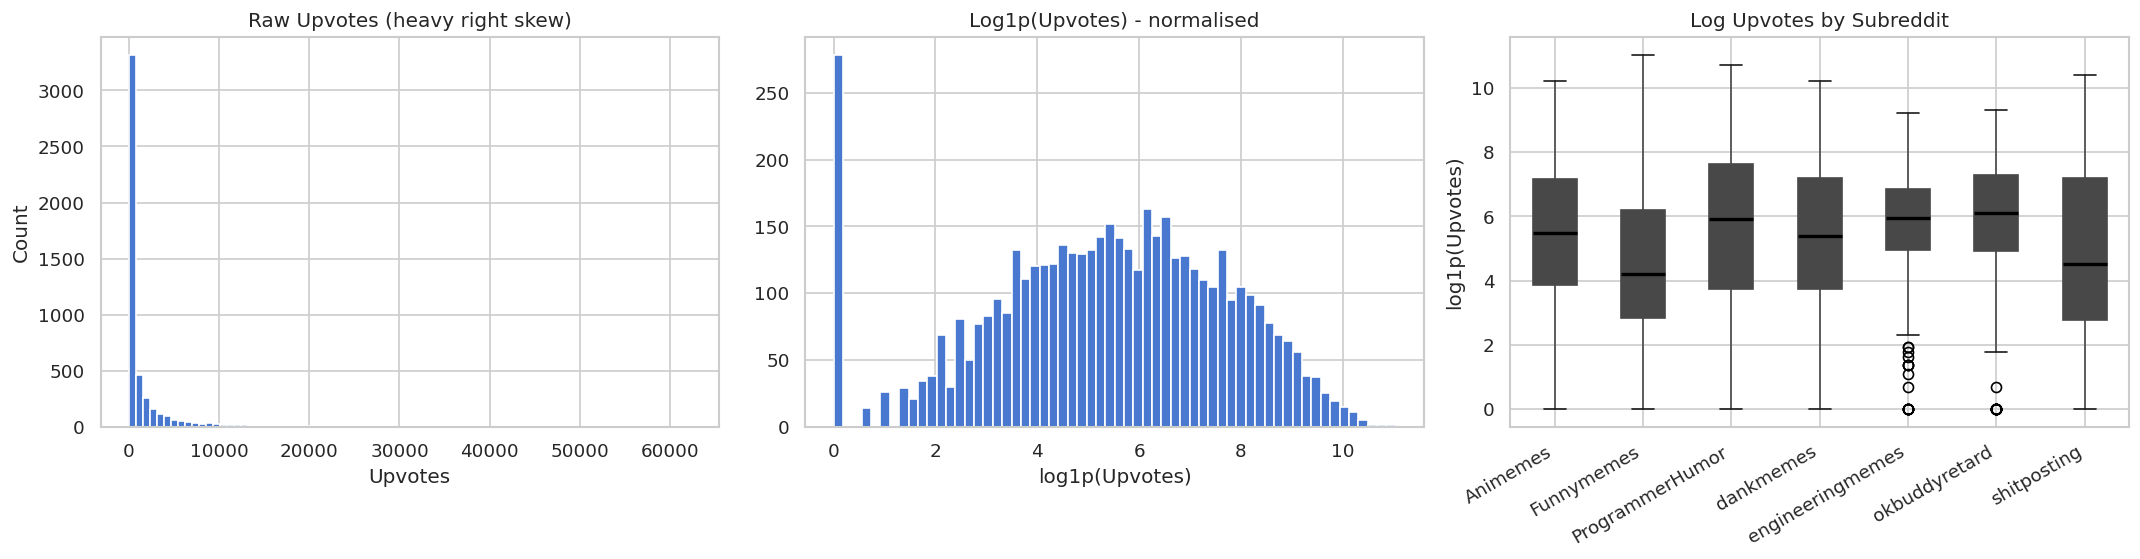


Upvote Summary Statistics:
count     4,821.0
mean      1,504.5
std       3,537.9
min           0.0
25%          44.0
50%         240.0
75%       1,202.0
max      62,256.0
Name: Upvotes, dtype: object

Virality threshold (75th pct) : 1,202 upvotes
Viral: 25.0%  |  Non-viral: 75.0%


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Target Variable: Upvotes', fontsize=14)

axes[0].hist(df['Upvotes'], bins=80, edgecolor='white')
axes[0].set_title('Raw Upvotes (heavy right skew)')
axes[0].set_xlabel('Upvotes')
axes[0].set_ylabel('Count')

axes[1].hist(df['log_upvotes'], bins=60, edgecolor='white')
axes[1].set_title('Log1p(Upvotes) - normalised')
axes[1].set_xlabel('log1p(Upvotes)')

df.boxplot(column='log_upvotes', by='Category', ax=axes[2],
           patch_artist=True, medianprops=dict(color='black', linewidth=2))
axes[2].set_title('Log Upvotes by Subreddit')
axes[2].set_xlabel('')
axes[2].set_ylabel('log1p(Upvotes)')
plt.sca(axes[2])
plt.xticks(rotation=30, ha='right')
plt.suptitle('')
plt.tight_layout()
plt.show()

print("\nUpvote Summary Statistics:")
print(df['Upvotes'].describe().apply(lambda x: f"{x:,.1f}"))
print(f"\nVirality threshold (75th pct) : {df['Upvotes'].quantile(0.75):,.0f} upvotes")
print(f"Viral: {df['is_viral'].mean()*100:.1f}%  |  Non-viral: {(1-df['is_viral'].mean())*100:.1f}%")

# Subreddit Level Analysis

Subreddit Statistics:
        Category  count  mean_upvotes  median_upvotes  std_upvotes  viral_rate
   okbuddyretard    699   1185.376252           444.0  1681.544863    0.296137
engineeringmemes    569    830.309315           381.0  1283.750849    0.195079
 ProgrammerHumor    803   2109.290162           369.0  4313.368877    0.322540
        Animemes    753   1522.982736           236.0  3325.975060    0.254980
       dankmemes    664   1673.203313           215.0  3467.481314    0.268072
     shitposting    603   2061.434494            91.0  4662.779047    0.258706
      Funnymemes    730   1037.530137            66.0  4079.707728    0.141096


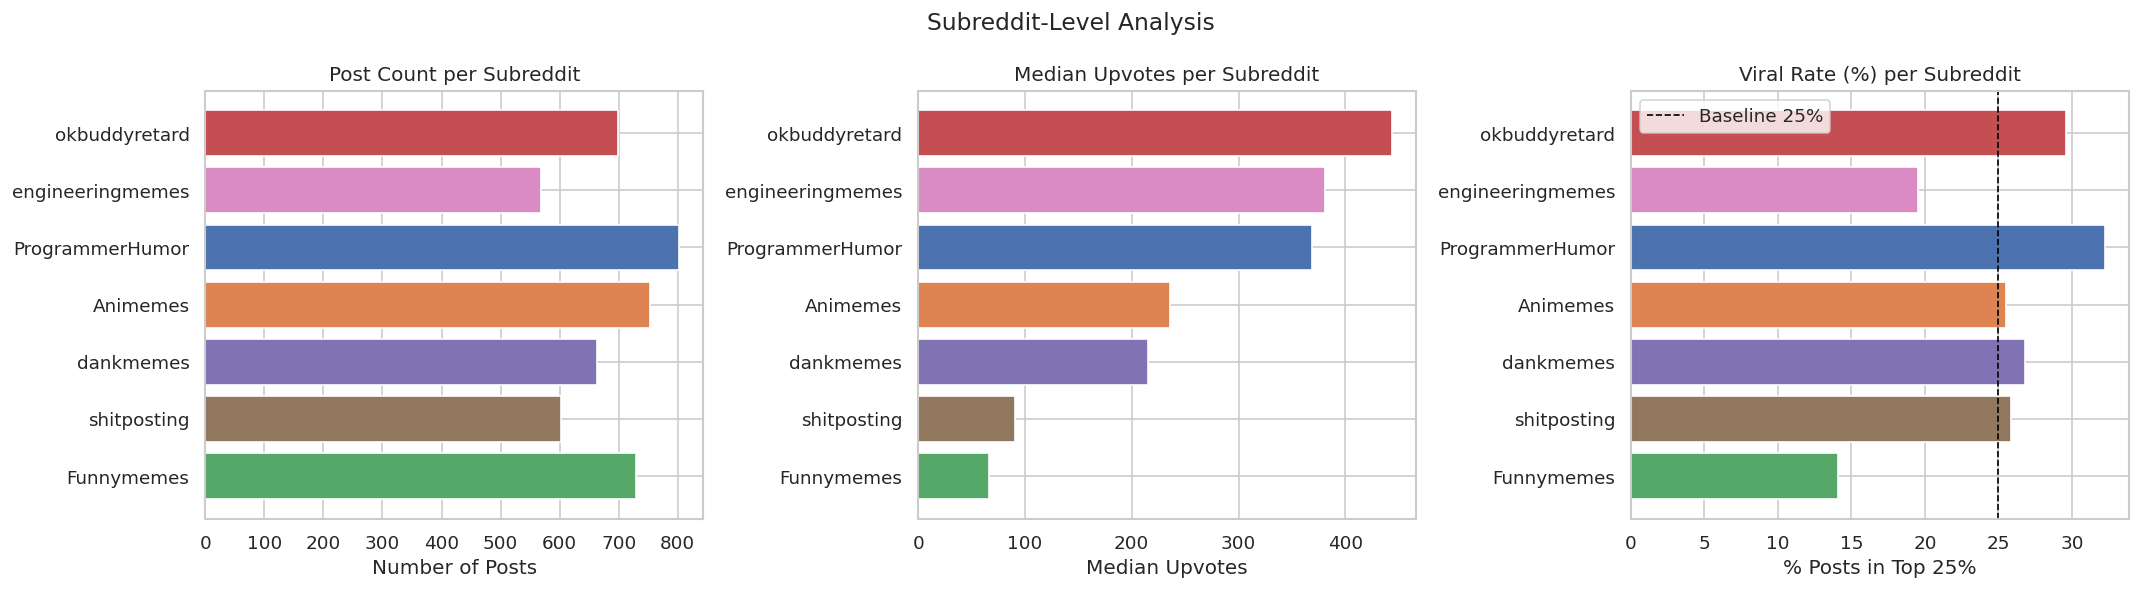

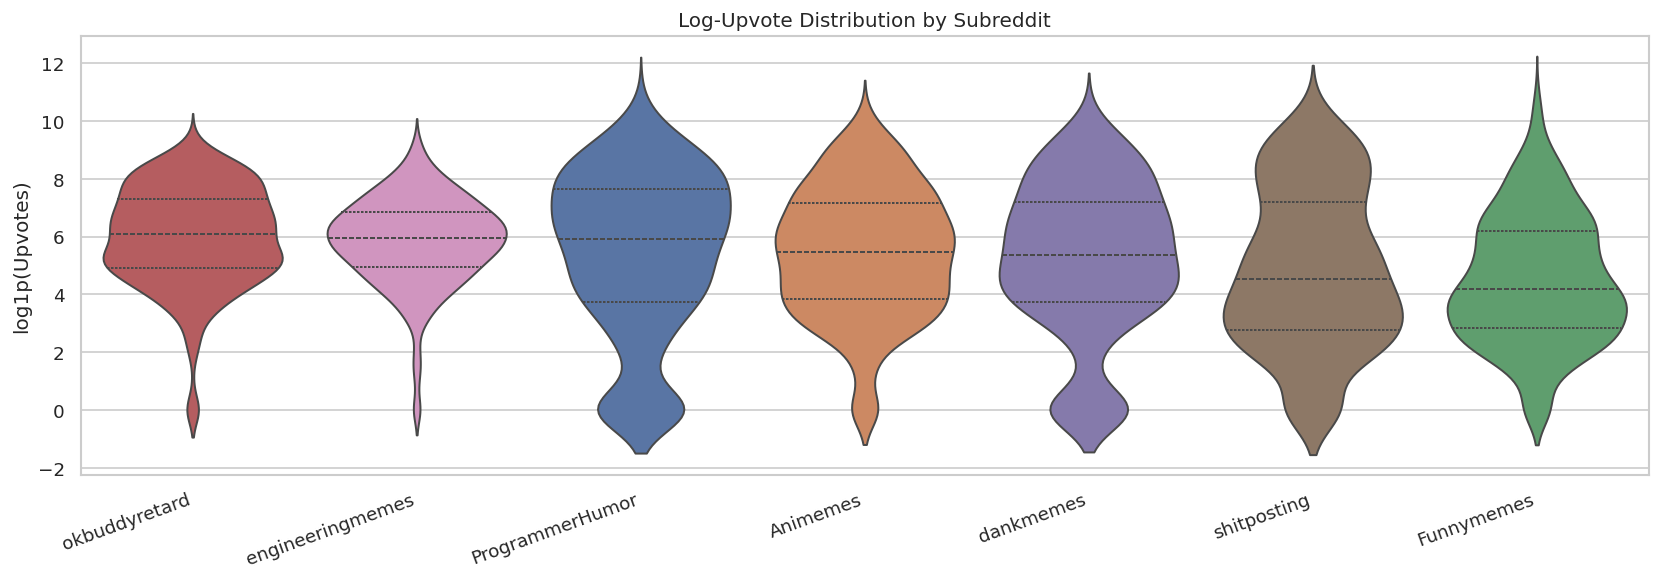

In [ ]:
sub_stats = df.groupby('Category').agg(
    count          = ('Upvotes', 'count'),
    mean_upvotes   = ('Upvotes', 'mean'),
    median_upvotes = ('Upvotes', 'median'),
    std_upvotes    = ('Upvotes', 'std'),
    viral_rate     = ('is_viral', 'mean'),
).reset_index().sort_values('median_upvotes', ascending=False)

print("Subreddit Statistics:")
print(sub_stats.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Subreddit-Level Analysis', fontsize=14)
colors = [SUBREDDIT_COLORS[s] for s in sub_stats['Category']]

axes[0].barh(sub_stats['Category'], sub_stats['count'], color=colors)
axes[0].set_title('Post Count per Subreddit')
axes[0].set_xlabel('Number of Posts')
axes[0].invert_yaxis()

axes[1].barh(sub_stats['Category'], sub_stats['median_upvotes'], color=colors)
axes[1].set_title('Median Upvotes per Subreddit')
axes[1].set_xlabel('Median Upvotes')
axes[1].invert_yaxis()

axes[2].barh(sub_stats['Category'], sub_stats['viral_rate'] * 100, color=colors)
axes[2].set_title('Viral Rate (%) per Subreddit')
axes[2].set_xlabel('% Posts in Top 25%')
axes[2].axvline(25, color='black', linestyle='--', linewidth=1, label='Baseline 25%')
axes[2].legend()
axes[2].invert_yaxis()
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))
order = sub_stats['Category'].tolist()
sns.violinplot(data=df, x='Category', y='log_upvotes', order=order,
               palette=SUBREDDIT_COLORS, inner='quartile', linewidth=1.2)
plt.title('Log-Upvote Distribution by Subreddit')
plt.xlabel('')
plt.ylabel('log1p(Upvotes)')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

# Text Feature

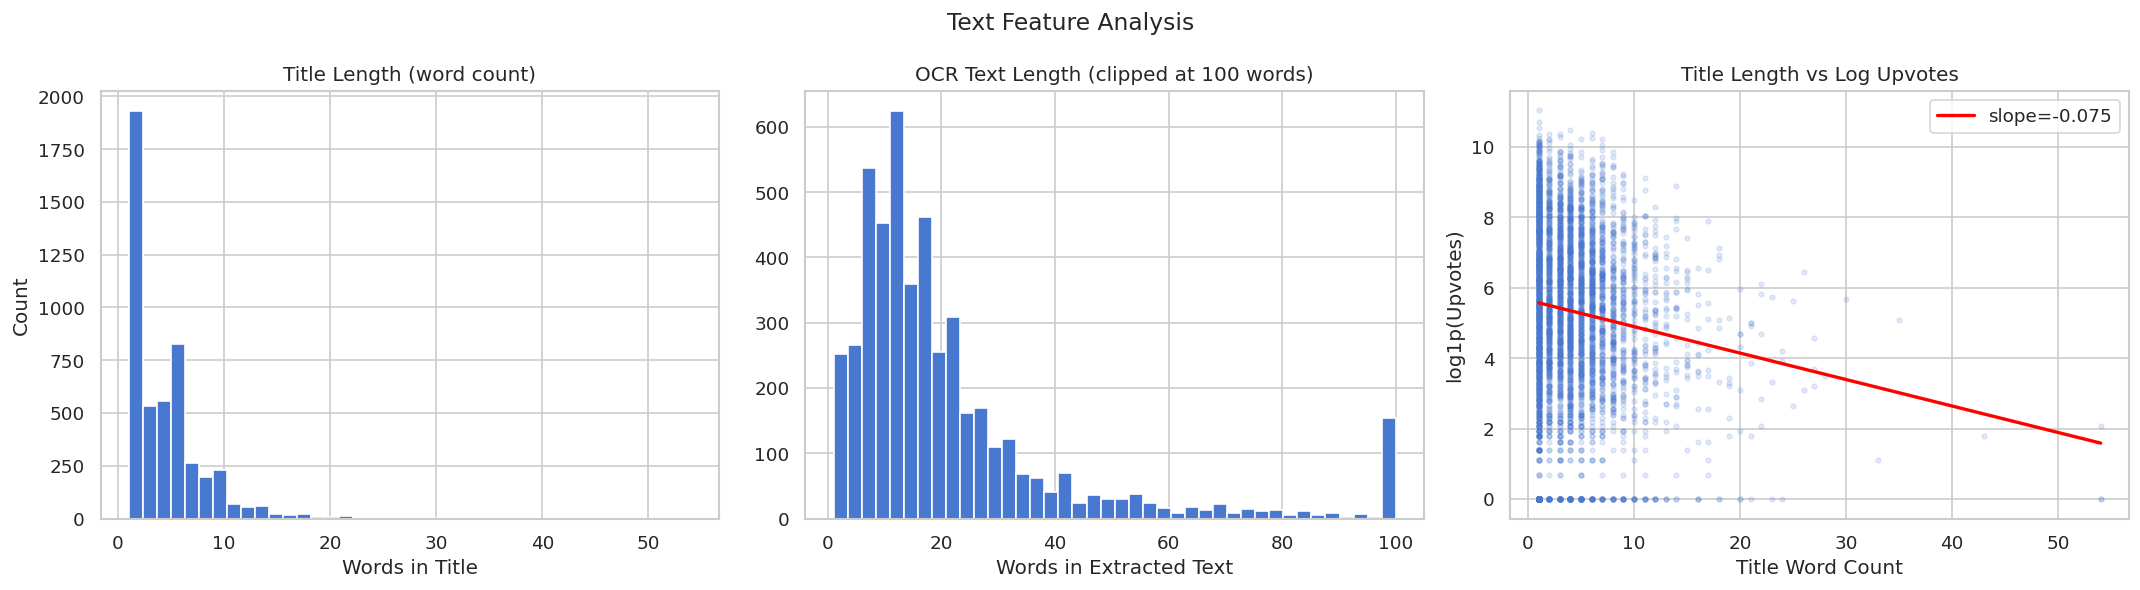


Correlations with Upvotes:
  title_len              : -0.120
  ocr_len                : +0.019
  Number of Comments     : +0.574
  Upvote Ratio           : +0.213
  Total Karma            : -0.012
  account_age_days       : -0.028


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Text Feature Analysis', fontsize=14)

axes[0].hist(df['title_len'], bins=40, edgecolor='white')
axes[0].set_title('Title Length (word count)')
axes[0].set_xlabel('Words in Title')
axes[0].set_ylabel('Count')

axes[1].hist(df['ocr_len'].clip(0, 100), bins=40, edgecolor='white')
axes[1].set_title('OCR Text Length (clipped at 100 words)')
axes[1].set_xlabel('Words in Extracted Text')

axes[2].scatter(df['title_len'], df['log_upvotes'], alpha=0.15, s=8)
m, b = np.polyfit(df['title_len'], df['log_upvotes'], 1)
xs = np.linspace(df['title_len'].min(), df['title_len'].max(), 100)
axes[2].plot(xs, m*xs + b, color='red', linewidth=2, label=f'slope={m:.3f}')
axes[2].set_title('Title Length vs Log Upvotes')
axes[2].set_xlabel('Title Word Count')
axes[2].set_ylabel('log1p(Upvotes)')
axes[2].legend()
plt.tight_layout()
plt.show()

print("\nCorrelations with Upvotes:")
for col in ['title_len', 'ocr_len', 'Number of Comments', 'Upvote Ratio', 'Total Karma', 'account_age_days']:
    r = df[[col, 'Upvotes']].dropna().corr().iloc[0, 1]
    print(f"  {col:<22} : {r:+.3f}")

# Sentiment Analysis

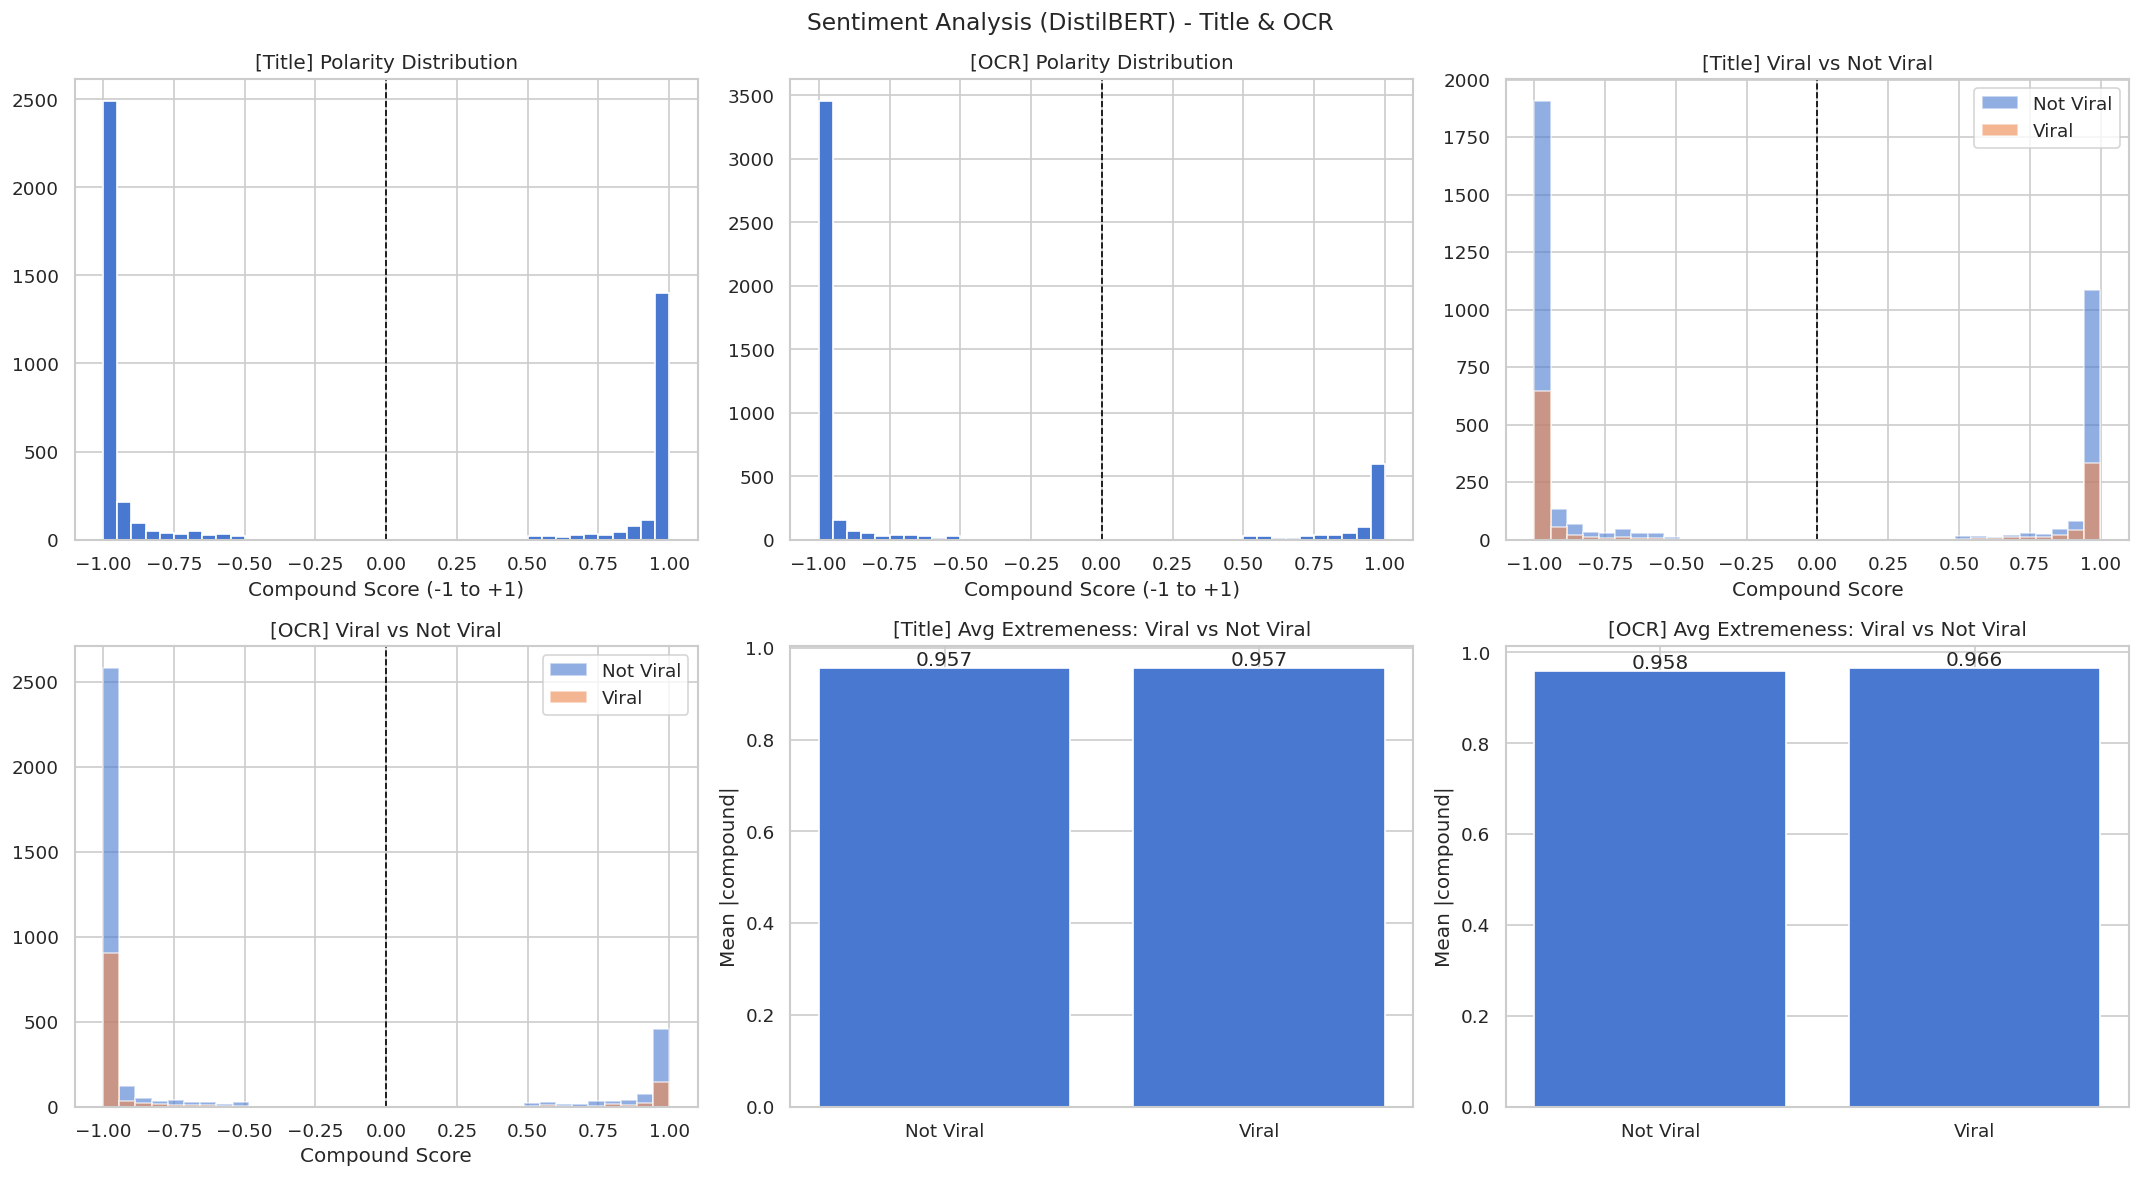


Correlation with Upvotes:
bert_title_compound    0.0070
bert_title_extreme     0.0182
bert_title_is_pos      0.0118
bert_title_is_neg     -0.0118
bert_ocr_compound     -0.0127
bert_ocr_extreme       0.0148
bert_ocr_is_pos       -0.0140
bert_ocr_is_neg        0.0140
dtype: float64

Mean by Viral vs Not Viral:
          bert_title_compound  bert_title_extreme  bert_title_is_pos  \
is_viral                                                               
0                      -0.252               0.957              0.368   
1                      -0.263               0.957              0.367   

          bert_title_is_neg  bert_ocr_compound  bert_ocr_extreme  \
is_viral                                                           
0                     0.632             -0.600             0.958   
1                     0.633             -0.644             0.966   

          bert_ocr_is_pos  bert_ocr_is_neg  
is_viral                                    
0                   0.196            

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Sentiment Analysis (DistilBERT) - Title & OCR", fontsize=14)

axes[0,0].hist(df["bert_title_compound"], bins=40, edgecolor="white")
axes[0,0].axvline(0, color="black", linestyle="--", linewidth=1)
axes[0,0].set_title("[Title] Polarity Distribution")
axes[0,0].set_xlabel("Compound Score (-1 to +1)")

axes[0,1].hist(df["bert_ocr_compound"], bins=40, edgecolor="white")
axes[0,1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[0,1].set_title("[OCR] Polarity Distribution")
axes[0,1].set_xlabel("Compound Score (-1 to +1)")

viral     = df[df["is_viral"] == 1]["bert_title_compound"]
not_viral = df[df["is_viral"] == 0]["bert_title_compound"]
axes[0,2].hist(not_viral, bins=35, alpha=0.6, label="Not Viral", edgecolor="white")
axes[0,2].hist(viral,     bins=35, alpha=0.6, label="Viral",     edgecolor="white")
axes[0,2].axvline(0, color="black", linestyle="--", linewidth=1)
axes[0,2].set_title("[Title] Viral vs Not Viral")
axes[0,2].set_xlabel("Compound Score")
axes[0,2].legend()

viral_ocr     = df[df["is_viral"] == 1]["bert_ocr_compound"]
not_viral_ocr = df[df["is_viral"] == 0]["bert_ocr_compound"]
axes[1,0].hist(not_viral_ocr, bins=35, alpha=0.6, label="Not Viral", edgecolor="white")
axes[1,0].hist(viral_ocr,     bins=35, alpha=0.6, label="Viral",     edgecolor="white")
axes[1,0].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1,0].set_title("[OCR] Viral vs Not Viral")
axes[1,0].set_xlabel("Compound Score")
axes[1,0].legend()

ext_title = df.groupby("is_viral")["bert_title_extreme"].mean()
axes[1,1].bar(["Not Viral", "Viral"], ext_title.values, edgecolor="white")
axes[1,1].set_title("[Title] Avg Extremeness: Viral vs Not Viral")
axes[1,1].set_ylabel("Mean |compound|")
for i, v in enumerate(ext_title.values):
    axes[1,1].text(i, v + 0.005, f"{v:.3f}", ha="center")

ext_ocr = df.groupby("is_viral")["bert_ocr_extreme"].mean()
axes[1,2].bar(["Not Viral", "Viral"], ext_ocr.values, edgecolor="white")
axes[1,2].set_title("[OCR] Avg Extremeness: Viral vs Not Viral")
axes[1,2].set_ylabel("Mean |compound|")
for i, v in enumerate(ext_ocr.values):
    axes[1,2].text(i, v + 0.005, f"{v:.3f}", ha="center")

plt.tight_layout()
plt.show()


BERT_COLS = [
    "bert_title_compound", "bert_title_extreme",
    "bert_title_is_pos",   "bert_title_is_neg",
    "bert_ocr_compound",   "bert_ocr_extreme",
    "bert_ocr_is_pos",     "bert_ocr_is_neg",
]
print("\nCorrelation with Upvotes:")
print(df[BERT_COLS].corrwith(np.log1p(df["Upvotes"])).round(4))

print("\nMean by Viral vs Not Viral:")
print(df.groupby("is_viral")[BERT_COLS].mean().round(3))

# Author Karma & Account Age

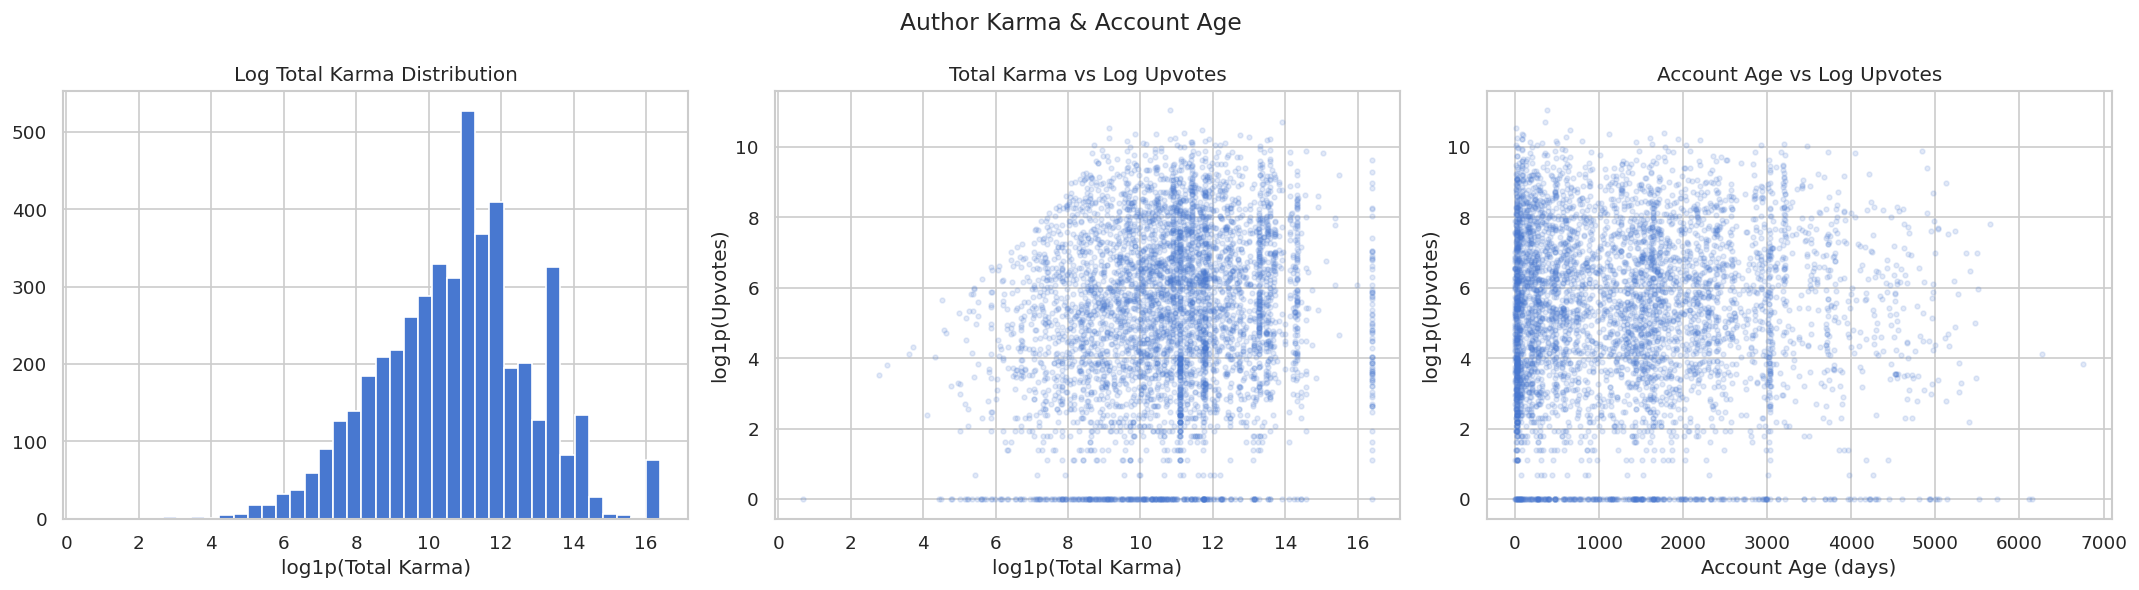

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Author Karma & Account Age', fontsize=14)

axes[0].hist(np.log1p(df['Total Karma']), bins=40, edgecolor='white')
axes[0].set_title('Log Total Karma Distribution')
axes[0].set_xlabel('log1p(Total Karma)')

axes[1].scatter(np.log1p(df['Total Karma']), df['log_upvotes'], alpha=0.15, s=8)
axes[1].set_title('Total Karma vs Log Upvotes')
axes[1].set_xlabel('log1p(Total Karma)')
axes[1].set_ylabel('log1p(Upvotes)')

axes[2].scatter(df['account_age_days'], df['log_upvotes'], alpha=0.15, s=8)
axes[2].set_title('Account Age vs Log Upvotes')
axes[2].set_xlabel('Account Age (days)')
axes[2].set_ylabel('log1p(Upvotes)')
plt.tight_layout()
plt.show()

# Correlation Matrix

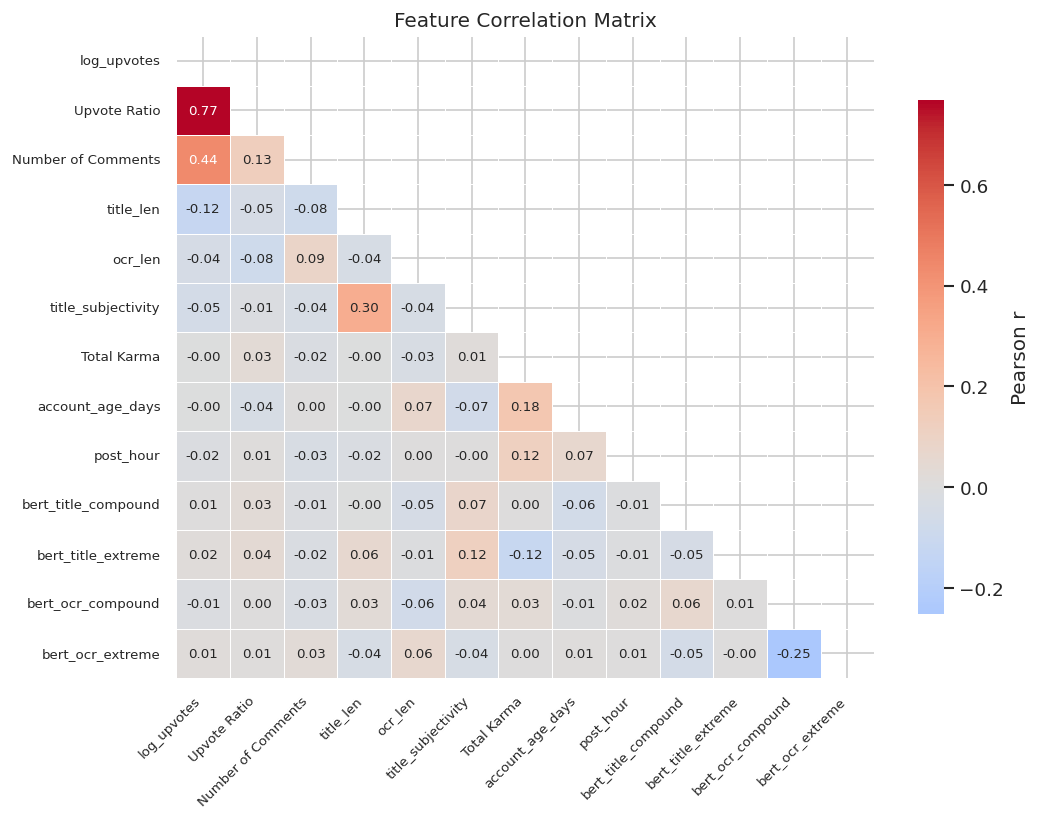

In [ ]:
corr_cols = corr_cols = ['log_upvotes','Upvote Ratio','Number of Comments',
                         'title_len','ocr_len','title_subjectivity',
                         'Total Karma','account_age_days','post_hour',
                         'bert_title_compound','bert_title_extreme',
                         'bert_ocr_compound','bert_ocr_extreme',]

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.4,
            annot_kws={'size': 8}, cbar_kws={'label': 'Pearson r', 'shrink': 0.8})
plt.title('Feature Correlation Matrix', fontsize=12)
plt.xticks(fontsize=8, rotation=45, ha='right')
plt.yticks(fontsize=8, rotation=0)
plt.tight_layout()
plt.show()

# Comments & Upvotes

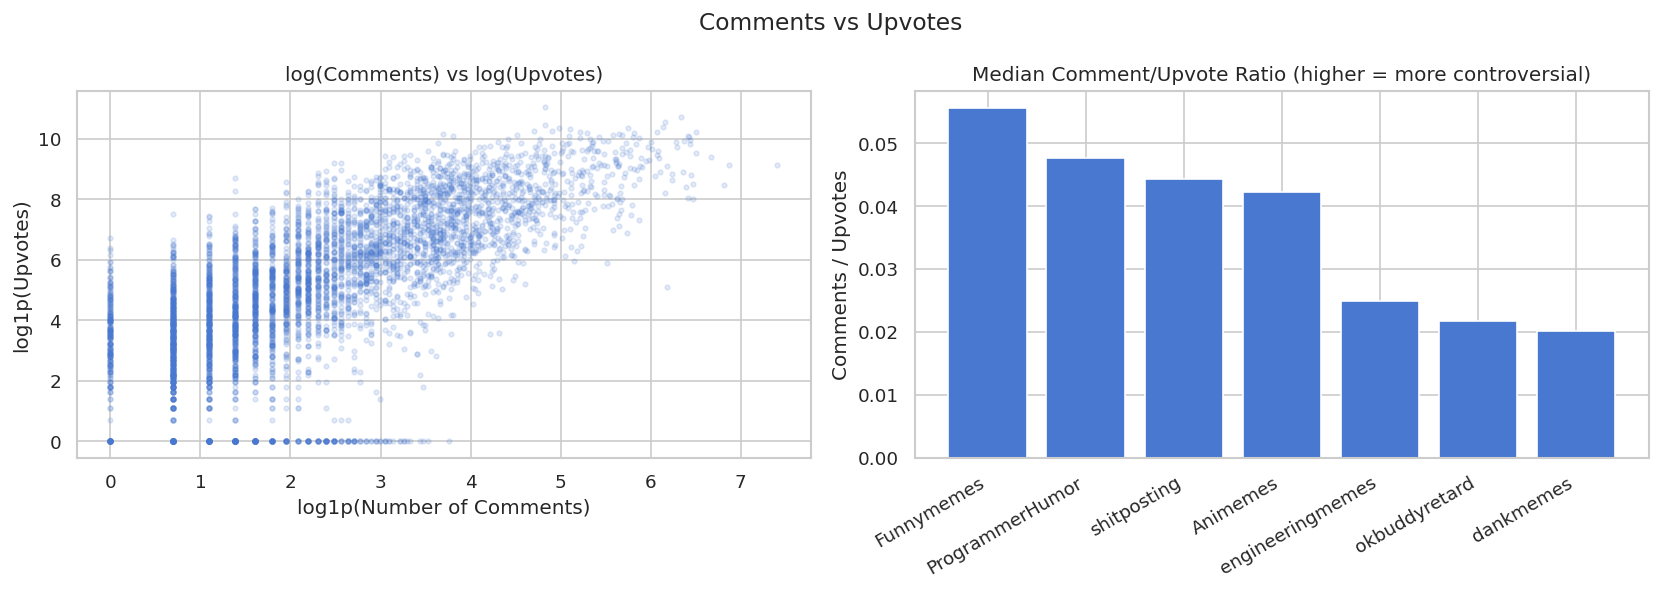

In [ ]:
df['comment_upvote_ratio'] = df['Number of Comments'] / (df['Upvotes'] + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Comments vs Upvotes', fontsize=14)

axes[0].scatter(np.log1p(df['Number of Comments']), df['log_upvotes'], alpha=0.15, s=8)
axes[0].set_title('log(Comments) vs log(Upvotes)')
axes[0].set_xlabel('log1p(Number of Comments)')
axes[0].set_ylabel('log1p(Upvotes)')

sub_ratio = df.groupby('Category')['comment_upvote_ratio'].median().sort_values(ascending=False)
axes[1].bar(sub_ratio.index, sub_ratio.values)
axes[1].set_title('Median Comment/Upvote Ratio (higher = more controversial)')
axes[1].set_ylabel('Comments / Upvotes')
axes[1].set_xticklabels(sub_ratio.index, rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [27]:
majority_acc = max(df['is_viral'].mean(), 1 - df['is_viral'].mean())

print("BASELINE SANITY CHECK")
print(f"Majority-class accuracy: {majority_acc*100:.1f}%")
print(f"Dummy F1 (majority class) : {2 * majority_acc * 0.25 / (majority_acc + 0.25):.3f}")
print(f"Mean upvotes: {df['Upvotes'].mean():,.0f}")
print(f"Median upvotes : {df['Upvotes'].median():,.0f}")
print(f"Top subreddit (median): {sub_stats.iloc[0]['Category']} ({sub_stats.iloc[0]['median_upvotes']:,.0f})")
print(f"Bottom subreddit (median) : {sub_stats.iloc[-1]['Category']} ({sub_stats.iloc[-1]['median_upvotes']:,.0f})")


BASELINE SANITY CHECK
Majority-class accuracy: 75.0%
Dummy F1 (majority class) : 0.375
Mean upvotes: 1,504
Median upvotes : 240
Top subreddit (median): okbuddyretard (444)
Bottom subreddit (median) : Funnymemes (66)
